In [41]:
using HDF5
using PyPlot
using ProgressBars
using JLD2
using Images, ImageFiltering
using Statistics
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

In [42]:
function load_imgs(filenames, pathdir)
    imgs_atoms, imgs_bkg, imgs_dark = [], [], []

    for filename in filenames
        filename = pathdir*filename
        h5open(filename, "r") do file
            img_atoms = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"]))
            img_bkg = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"]))
            img_dark = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"]))
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark)
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark
end

function crop_imgs(imgs, x_crop, y_crop, mask)
    imgs_crop = []
    for i = 1:length(imgs)
        img_crop = imgs[i][y_crop, x_crop]
        push!(imgs_crop, img_crop .* mask)
    end
    return imgs_crop
end

function compute_OD_high_low_intensity(imgs_atoms, imgs_bkg, imgs_dark, i_sat, t_exp)
    ODs = []
    for i in 1:length(imgs_atoms)
        OD = (imgs_atoms[i] .- imgs_dark[i]) ./ (imgs_bkg[i] .- imgs_dark[i])

        OD[OD .< 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
        OD .= -log10.(OD)
        OD[isnan.(OD)] .= 0 # Map Nan values to 0

        # For high intensity, modified OD formula
        if i_sat >= 1
            OD .+= (imgs_bkg[i] .- imgs_atoms[i]) / (7000*t_exp/5e-6)
        end
        push!(ODs, OD)
    end
    return ODs
end

function mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)
    mask = zeros(Integer, (length(y_crop), length(x_crop)))
    X = range(0, length(y_crop)-1) .- yc
    Y = range(0, length(x_crop)-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

function smooth_imgs(img, size_kernel)
    flat_kernel = ones(size_kernel, size_kernel)/size_kernel^2
    img_smooth = imfilter(img, flat_kernel)
    return img_smooth
end

function normalize(img)
    img_norm = (img .- minimum(img)) ./ (maximum(img)-minimum(img))
    return img_norm
end

function find_droplets_radius_range(img, droplet_radius_range, threshold_droplets_range)
    blob_centers = []
    response = zeros(size(img))

    for droplet_radius in droplet_radius_range
        log_kernel = Kernel.gaussian(droplet_radius)
        response .+= imfilter(img, log_kernel)
        response = response .* droplet_radius^2
    end
    
    blobs = response .> threshold_droplets_range * std(img)^(1/2) # Adaptative threshold depending on the std of the img

    label_blobs = label_components(blobs) # Separate the blobs
    for label in 1:maximum(label_blobs) # Find the center of each blob
        inds = findall(label_blobs .== label)
        push!(blob_centers, [mean([i[2]-1 for i in inds]), mean([i[1]-1 for i in inds])])
    end

    return blob_centers, label_blobs
end

find_droplets_radius_range (generic function with 1 method)

In [ ]:
file = h5open("Y:\\TwoDGas\\2026\\01\\19\\0046\\2026-01-19_0046_TwoDGas_00.h5", "r")
read_attribute(file["globals"], "vert_abs_img_amp_high")

0.1

In [43]:
pathdir_date = "Y:/TwoDGas/2026/01/19"
dir_names_datasets = readdir(pathdir_date)
dir_names_datasets = dir_names_datasets[dir_names_datasets .!= ".DS_Store"]
dir_names_datasets = dir_names_datasets[end-4:end-3]
I_inc = [0.04, 0.1, 0.5, 3, 5.2, 6].*1e-3 # In W
sat_exp = [0.004, 0.4, 1.7, 4.7, 10, 16.5, 23, 28.5, 33, 37.5] # Estimated saturation parameter
I_sat_range = [0:0.1:maximum(sat_exp);]
τ_exp = 5e-6 # In s
x_crop = [1255:1575;]
y_crop = [1890:2260;]
wrong_shots = [1, 2, 3, 4, 11, 21, 31, 41]
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ
γ = 32.7e6 # In Hz
I_inc_range = [0.01:0.01:10;].*1e-3 # Intensity of the laser in W
I_sat_cst = ustrip(ħ)*γ*ω0^3 / (12π*ustrip(c_0)^2)

N_atoms_per_droplet = 15000

xc, yc, a, b, θ = 140, 200, 70, 40, 1.1;

### Create folders

In [ ]:
if !isdir("imgs")
    mkdir("imgs")
end
if !isdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_"))
    mkdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_"))
end


if !isdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/ODs_mask")
    mkdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/ODs_mask")
end

if !isdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/neg_ODs_mask")
    mkdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/neg_ODs_mask")
end

if !isdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/droplets")
    mkdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/droplets")
end

for i = 1:length(dir_names_datasets)
    if !isdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/ODs_mask/"*dir_names_datasets[i])
        mkdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/ODs_mask/"*dir_names_datasets[i])
    end

    if !isdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/droplets/"*(dir_names_datasets[i]))
        mkdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/droplets/"*(dir_names_datasets[i]))
    end
    
    if !isdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/neg_ODs_mask/"*dir_names_datasets[i])
        mkdir("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/neg_ODs_mask/"*dir_names_datasets[i])
    end
end

# Import and crop the images

In [ ]:
imgs_atoms_crop_datasets, imgs_bkg_crop_datasets, imgs_dark_crop_datasets = [], [], []
mask = mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)

for dir_name_datasets in ProgressBar(dir_names_datasets)
    Imgs_atms, Imgs_bkg, Imgs_dark = [], [], []
    files_path = readdir(pathdir_date*"/"*dir_name_datasets)

    for j = 1:5:length(files_path)
        imgs_atoms, imgs_bkg, imgs_dark = load_imgs(files_path[j:j+4], pathdir_date*"/"*dir_name_datasets*"/")
        imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop = crop_imgs(imgs_atoms, x_crop, y_crop, mask), crop_imgs(imgs_bkg, x_crop, y_crop, mask), crop_imgs(imgs_dark, x_crop, y_crop, mask)
        push!(Imgs_atms, imgs_atoms_crop), push!(Imgs_bkg, imgs_bkg_crop), push!(Imgs_dark, imgs_dark_crop)
    end
    push!(imgs_atoms_crop_datasets, Imgs_atms), push!(imgs_bkg_crop_datasets, Imgs_bkg), push!(imgs_dark_crop_datasets, Imgs_dark)
end

In [ ]:
@save "Imgs_crop_mask.jld2" imgs_atoms_crop_datasets imgs_bkg_crop_datasets imgs_dark_crop_datasets

In [4]:
@load "Imgs_crop_mask.jld2" imgs_atoms_crop_datasets imgs_bkg_crop_datasets imgs_dark_crop_datasets;

# Compute the ODs

In [38]:
imgs_atoms_crop_datasets[1][1]

5-element Vector{Any}:
 [0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0]
 [0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0]
 [0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0]
 [0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0]
 [0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0]

In [ ]:
ODs_datasets = []
for i in ProgressBar(1:length(imgs_atoms_crop_datasets))
    ODs = []
    for j = 1:length(imgs_atoms_crop_datasets[1])
        push!(ODs, compute_OD_high_low_intensity(imgs_atoms_crop_datasets[i][j], imgs_bkg_crop_datasets[i][j], imgs_dark_crop_datasets[i][j], sat_exp[i], τ_exp))
    end
    push!(ODs_datasets, ODs)
end

In [ ]:
@save "ODs_crop_mask.jld2" ODs_datasets

In [5]:
@load "ODs_crop_mask.jld2" ODs_datasets;

# Save the ODs images

### ODs

In [ ]:
close("all")
fig, axs = subplots()

for (i, ODs) in ProgressBar(enumerate(ODs_datasets))
    for (j, OD) in enumerate(ODs)
        for k in 1:5
            img = axs.imshow(OD[k], cmap="plasma") #, aspect="auto"
            cb = colorbar(img)
            savefig("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/ODs_mask"*"/"*dir_names_datasets[i]*"/$(5*(j-1)+k).png")
            cb.remove()
            axs.clear()
        end
    end
end
close("all")

### Negative ODs

In [ ]:
close("all")
fig, axs = subplots()

for (i, ODs) in ProgressBar(enumerate(ODs_datasets))
    for (j, OD) in enumerate(ODs)
        for k in 1:5
            img = axs.imshow(OD[k], cmap="bone", vmin=-0.2, vmax=0) #, aspect="auto"
            cb = colorbar(img)
            savefig("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/neg_ODs_mask"*"/"*dir_names_datasets[i]*"/$(5*(j-1)+k).png")
            cb.remove()
            axs.clear()
        end
    end
end
close("all")

# Count the droplets

In [30]:
size_kernel_smooth = 5
droplet_radius_range = [3:0.2:4;]
threshold_droplets_range = 6500000
nbr_droplets = zeros((length(ODs_datasets), length(ODs_datasets[1]), length(ODs_datasets[1][1])))
centers_droplets = []
save_imgs = true

close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))

for idx_dataset in ProgressBar(1:length(ODs_datasets))
    centers_drop = []
    for (i, OD) in enumerate(ODs_datasets[idx_dataset])
        for k = 1:5
            smooth_norm_OD = normalize(smooth_imgs(OD[k], size_kernel_smooth)) # Normalize to gaussian kernel
            centers, label_blobs = find_droplets_radius_range(smooth_norm_OD, droplet_radius_range, threshold_droplets_range)

            if save_imgs
                axs[1].imshow(smooth_norm_OD)
                axs[2].imshow(label_blobs)
                axs[2].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")
                axs[3].imshow(OD[k])
                axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r", alpha=0.5)

                savefig("imgs/"*join(split(pathdir_date, "/")[3:end], "_")*"/droplets/$(dir_names_datasets[idx_dataset])/$(5*(i-1)+k).png")
                for ax in axs
                    ax.clear()
                end
            end

            nbr_droplets[idx_dataset, i, k] = length(centers)
            push!(centers_drop, centers)
        end
    end
    push!(centers_droplets, centers_drop)
end

close("all")

0.0%┣                                                ┫ 0/2 [00:00<00:00, -0s/it]
50.0%┣█████████████████████▌                     ┫ 1/2 [00:14<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████████┫ 2/2 [00:27<00:00, 27s/it]
100.0%┣██████████████████████████████████████████████┫ 2/2 [00:27<00:00, 27s/it]


In [31]:
N_atoms_per_droplet = 15000
radius_droplets = 10
radius_droplets_nomalised = radius_droplets*0.187e-6/λ

smooth_kernel_r_range = [-size_kernel_smooth/2:1e-2:size_kernel_smooth/2;]
N_atoms_center_smooth = sum(N_atoms_per_droplet/(sqrt(2π)*radius_droplets_nomalised) * exp.(-(smooth_kernel_r_range.^2)./(2*radius_droplets_nomalised^2)).* 1e-2)

6408.279801318208

# Compute the intensity at the center of the droplets for each dataset

In [32]:
Sum_mean_Iatoms_center_drop = zeros((length(ODs_datasets[1]), length(ODs_datasets[1][1])))
Sum_mean_Ibkg_center_drop = zeros((length(ODs_datasets[1]), length(ODs_datasets[1][1])))
Sum_mean_Idark_center_drop = zeros((length(ODs_datasets[1]), length(ODs_datasets[1][1])))

Convertion_factor = (0.85 * 0.107 * τ_exp)

size_kernel_smooth = 5

for (i, ODs) in ProgressBar(enumerate(ODs_datasets[1]))
    for j in eachindex(ODs)
        centers_drops = centers_droplets[1][i]
        if (i-1)*5+j ∉ wrong_shots 
            for d in eachindex(centers_drops)
                i_at = smooth_imgs(imgs_atoms_crop_datasets[1][i][j], size_kernel_smooth)
                i_bkg = smooth_imgs(imgs_bkg_crop_datasets[1][i][j], size_kernel_smooth)
                i_dark = smooth_imgs(imgs_dark_crop_datasets[1][i][j], size_kernel_smooth)
                Sum_mean_Iatoms_center_drop[i, j] += i_at[round(Int, centers_drops[d][2]), round(Int, centers_drops[d][1])]
                Sum_mean_Ibkg_center_drop[i, j] += i_bkg[round(Int, centers_drops[d][2]), round(Int, centers_drops[d][1])]
                Sum_mean_Idark_center_drop[i, j] += i_dark[round(Int, centers_drops[d][2]), round(Int, centers_drops[d][1])]
            end
            Sum_mean_Iatoms_center_drop[i, j] /= nbr_droplets[1, i, j]
            Sum_mean_Ibkg_center_drop[i, j] /= nbr_droplets[1, i, j]
            Sum_mean_Idark_center_drop[i, j] /= nbr_droplets[1, i, j]
        end
    end
end

Sum_mean_Iatoms_center_drop /= N_atoms_center_smooth*Convertion_factor
Sum_mean_Ibkg_center_drop /= N_atoms_center_smooth*Convertion_factor
Sum_mean_Idark_center_drop /= N_atoms_center_smooth*Convertion_factor;



0.0%┣                                               ┫ 0/10 [00:00<00:00, -0s/it]
30.0%┣█████████████▉                                ┫ 3/10 [00:00<00:00, 31it/s]
50.0%┣███████████████████████                       ┫ 5/10 [00:00<00:00, 16it/s]
60.0%┣███████████████████████████▋                  ┫ 6/10 [00:00<00:00, 13it/s]
70.0%┣████████████████████████████████▏             ┫ 7/10 [00:01<00:00, 10it/s]
80.0%┣█████████████████████████████████████▋         ┫ 8/10 [00:01<00:00, 9it/s]
90.0%┣██████████████████████████████████████████▎    ┫ 9/10 [00:01<00:00, 8it/s]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:01<00:00, 7it/s]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:01<00:00, 7it/s]


In [33]:
Mean_sum_mean_Iatoms_center_drop = vec(mean(Sum_mean_Iatoms_center_drop, dims=2))
Mean_sum_mean_Ibkg_center_drop = vec(mean(Sum_mean_Ibkg_center_drop, dims=2))
Mean_sum_mean_Idark_center_drop = vec(mean(Sum_mean_Idark_center_drop, dims=2))
Std_sum_mean_Iatoms_center_drop = vec(std(Sum_mean_Iatoms_center_drop, dims=2))
Std_sum_mean_Ibkg_center_drop = vec(std(Sum_mean_Ibkg_center_drop, dims=2))
Std_sum_mean_Idark_center_drop = vec(std(Sum_mean_Idark_center_drop, dims=2));

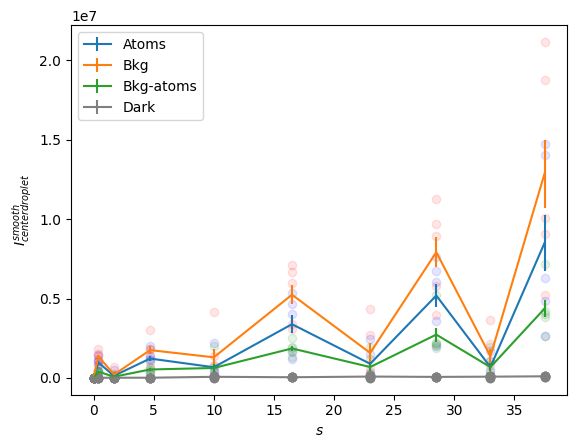

In [34]:
close("all")
fig = subplots()

errorbar(sat_exp, Mean_sum_mean_Iatoms_center_drop, yerr=Std_sum_mean_Iatoms_center_drop/sqrt(length(ODs_datasets[1])), label="Atoms")
errorbar(sat_exp, Mean_sum_mean_Ibkg_center_drop, yerr=Std_sum_mean_Ibkg_center_drop/sqrt(length(ODs_datasets[1])), label="Bkg")
errorbar(sat_exp, Mean_sum_mean_Ibkg_center_drop-Mean_sum_mean_Iatoms_center_drop, yerr=vec(std(Sum_mean_Ibkg_center_drop-Sum_mean_Iatoms_center_drop, dims=2))/sqrt(length(ODs_datasets[1])), label="Bkg-atoms")
errorbar(sat_exp, Mean_sum_mean_Idark_center_drop, yerr=Std_sum_mean_Idark_center_drop/sqrt(length(ODs_datasets[1])), label="Dark", color="grey")


for (i, ODs) in enumerate(ODs_datasets[1])
    for j in 1:length(ODs)
        scatter(sat_exp[i], Sum_mean_Iatoms_center_drop[i, j], color="b", alpha = 0.1)
        scatter(sat_exp[i], Sum_mean_Ibkg_center_drop[i, j], color="r", alpha = 0.1)
        scatter(sat_exp[i], Sum_mean_Ibkg_center_drop[i, j]-Sum_mean_Iatoms_center_drop[i, j], color="g", alpha = 0.1)
        scatter(sat_exp[i], Sum_mean_Idark_center_drop[i, j], color="grey")
    end
end

xlabel(L"s")
ylabel(L"I_{center droplet}^{smooth}")

legend()

# pygui(true); show();
pygui(false);

In [ ]:
close("all")
fig = subplots()

errorbar(sat_exp, Mean_sum_mean_Iatoms_center_drop, yerr=Std_sum_mean_Iatoms_center_drop/sqrt(length(ODs_datasets[1])), label="Atoms")
errorbar(sat_exp, Mean_sum_mean_Ibkg_center_drop, yerr=Std_sum_mean_Ibkg_center_drop/sqrt(length(ODs_datasets[1])), label="Bkg")
errorbar(sat_exp, Mean_sum_mean_Ibkg_center_drop-Mean_sum_mean_Iatoms_center_drop, yerr=vec(std(Sum_mean_Ibkg_center_drop-Sum_mean_Iatoms_center_drop, dims=2))/sqrt(length(ODs_datasets[1])), label="Bkg-atoms")
errorbar(sat_exp, Mean_sum_mean_Idark_center_drop, yerr=Std_sum_mean_Idark_center_drop/sqrt(length(ODs_datasets[1])), label="Dark", color="grey")


for (i, ODs) in enumerate(ODs_datasets[1])
    for j in 1:length(ODs)
        
        scatter(sat_exp[i], Sum_mean_Iatoms_center_drop[i, j], color="b", alpha = 0.1)
        scatter(sat_exp[i], Sum_mean_Ibkg_center_drop[i, j], color="r", alpha = 0.1)
        scatter(sat_exp[i], Sum_mean_Ibkg_center_drop[i, j]-Sum_mean_Iatoms_center_drop[i, j], color="g", alpha = 0.1)
        scatter(sat_exp[i], Sum_mean_Idark_center_drop[i, j], color="grey")
    end
end

xlabel(L"s")
ylabel(L"I_{center droplet}^{smooth}")

legend()

# pygui(true); show();
pygui(false);

# Brouillons

In [ ]:
# files_path = pathdir_date*"/"*dir_names_datasets[1]*"/"*readdir(pathdir_date*"/"*dir_names_datasets[1])[50]

# file = h5open(files_path, "r")
# img_atoms = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"]))
# img_bkg = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"]))

# x_crop = [1255:1575;]
# y_crop = [1890:2260;]

# close("all")
# figure, axs = subplots(1, 2, figsize=(10, 5))
# axs[1].imshow(img_atoms[y_crop, x_crop])
# axs[2].imshow(crop_imgs([img_atoms], x_crop, y_crop, mask)[1])
# pygui(false)

# Modelling one droplet


# close("all")
# fig = subplots()

# N_atoms_per_droplet = 15000

# radius_droplets_nomalised = radius_droplets*0.187e-6/λ
# r = [-radius_droplets_nomalised*5:1e-2:radius_droplets_nomalised*5;]
# plot(r, N_atoms_per_droplet/(sqrt(2π)*radius_droplets_nomalised) * exp.(-(r.^2)./(2*radius_droplets_nomalised^2)))

# vlines(-size_kernel_smooth/2*0.187e-6/λ, 0, N_atoms_per_droplet/(sqrt(2π)*radius_droplets_nomalised), color="grey", linestyle="--")
# vlines(size_kernel_smooth/2*0.187e-6/λ, 0, N_atoms_per_droplet/(sqrt(2π)*radius_droplets_nomalised), color="grey", linestyle="--")
# xlabel(L"r/\lambda")
# ylabel(L"n_0")
# pygui(false)


# smooth_kernel_r_range = [-size_kernel_smooth/2:1e-2:size_kernel_smooth/2;]
# N_atoms_center_smooth = sum(N_atoms_per_droplet/(sqrt(2π)*radius_droplets_nomalised) * exp.(-(smooth_kernel_r_range.^2)./(2*radius_droplets_nomalised^2)).* 1e-2)

# close("all")
# fig, axs = subplots(1, 3, figsize=(10, 5))
# axs[1].imshow(ODs_datasets[end][1])
# axs[1].set_xlim(119, 140)
# axs[1].set_ylim(200, 179)


# img_exp = axs[2].imshow(smooth_imgs(ODs_datasets[end][1], size_kernel_smooth))
# axs[2].set_xlim(119, 140)
# axs[2].set_ylim(200, 179)

# x = -10:10
# y = -10:10
# radius_droplets = 10
# z = exp.(-abs.((x' .* ones(length(y))) .+ 1im .* (ones(length(x))' .* y))^2/(2*radius_droplets^2))

# axs[3].imshow(z)

# # pygui(true); show()
# pygui(false);